<a href="https://colab.research.google.com/github/joeLinc123/world-cup-sentiment/blob/main/world_cup_fan_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

World cup sentiment tracker proj

Steps to this project

First - scrape tweets, for each world cup team
Second - Run sentiment analysis in real time during tournament
Third - Plot fan sentiment for each team, and analyse results

For sentiment analysis start off with basic binary analysis, if a tweet is pos or negative

then flesh out to a more granular analysis

Attempt using nltk

In [11]:
pip install atproto

In [12]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from atproto import Client
from transformers import pipeline
import matplotlib.pyplot as plt
from google.colab import userdata

In [13]:
#test - i actually like thomas tuchel!!

nltk.download("vader_lexicon")

analyser = SentimentIntensityAnalyzer()
sentence = "I fucking hate thomas tuchel, hes a twat and England are never going to win the world cup with him."

sentiment_scores = analyser.polarity_scores(sentence)
print(sentiment_scores)

{'neg': 0.433, 'neu': 0.567, 'pos': 0.0, 'compound': -0.9093}


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


scraping tweets from twitter

CHANGE I AM NOT USING TWITTER SCAMMING BASTARDS

In [14]:
app_passwd = userdata.get('app_psswd')

In [15]:
client = Client()
client.login("jobo03098.bsky.social",app_passwd)

ProfileViewDetailed(did='did:plc:l7ygjkpfp7x4grcaogq4dft5', handle='jobo03098.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=ProfileAssociatedChat(allow_incoming='none', allow_group_invites=None, py_type='app.bsky.actor.defs#profileAssociatedChat'), feedgens=0, germ=None, labeler=False, lists=0, starter_packs=0, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:l7ygjkpfp7x4grcaogq4dft5/bafkreigwvcfzls5tiufy7jvebklnoeyf2qrlpvczaznicvtfrgnrjikdsa', banner='https://cdn.bsky.app/img/banner/plain/did:plc:l7ygjkpfp7x4grcaogq4dft5/bafkreiajyckrgpo7jeaipqodcx2yc2y4j5pxny3bj5ddhebiznt6tzy6dy', created_at='2024-11-15T12:26:16.329Z', debug=None, description=None, display_name='', followers_count=12, follows_count=115, indexed_at='2024-11-15T12:43:15.629Z', joined_via_starter_pack=No

In [16]:
def search_team(team_name, limit=100):
  response = client.app.bsky.feed.search_posts(
      params={"q":team_name, "limit":limit}
  )
  return [post.record.text for post in response.posts]

england_posts = search_team(team_name="England")


In [17]:
print(england_posts)

['2026-06-16 21:02:36 - UK Government: The UK Health Security Service is deploying seven public health experts from the Public Health England Rapid Support Team to the Democratic Republic of the Congo and surrounding areas to respond to the Ebola outbreak.', '2026-06-16 21:02:36 - UK Government: The UK Health Security Service is deploying seven public health experts from the Public Health England Rapid Support Team to the Democratic Republic of the Congo and surrounding areas to respond to the Ebola outbreak.', 'WORLD CUP 2026\nLive on The Turtle BIG SCREEN\xa0\nTOMORROW!\n---------\nENGLAND v CROATIA\n9PM - WEDS 17th JUNE', "If rumours are true. In the PL there's hardly any viable option imho and looking at other European top leagues it's hard to find a player that will be 'guaranteed' to score 15+ goals in a debut season in England. \n\nWhich sort of leads me to the obvious q; are strikers a doing breed?", "There would be no Israel without England. The US has nothing to do with it.\n

In [18]:
sentiment = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment"
)


label_map = {
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive",
    "team":"team"
}


def analyse_posts(team, limit=100):
  response = client.app.bsky.feed.search_posts(
      params={"q":team,"limit":limit}
  )
  posts = [post.record.text for post in response.posts]
  response = sentiment(posts)
  summary = {"positive":0, "neutral":0, "negative":0,"team":team}
  for result in response:
    summary[label_map[result["label"]]] += 1
  return summary





Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [19]:
teams = ["England World Cup", "Brazil World Cup", "Scotland World Cup"]
all_results = []
for team in teams:
  summary = analyse_posts(team)
  summary["team"] = team
  all_results.append(summary)
  print("{} sentiment on world cup".format(team))
  print(summary)


England World Cup sentiment on world cup
{'positive': 14, 'neutral': 58, 'negative': 28, 'team': 'England World Cup'}
Brazil World Cup sentiment on world cup
{'positive': 17, 'neutral': 62, 'negative': 20, 'team': 'Brazil World Cup'}
Scotland World Cup sentiment on world cup
{'positive': 26, 'neutral': 61, 'negative': 13, 'team': 'Scotland World Cup'}


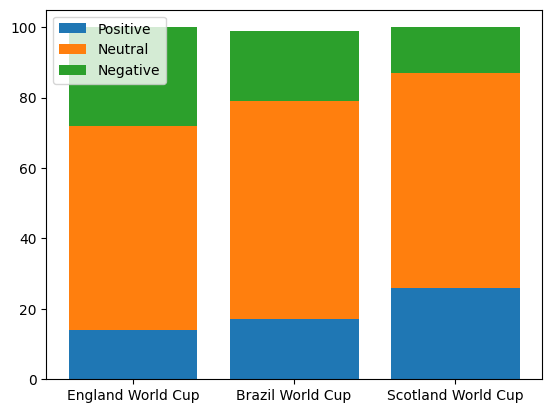

In [20]:
teams_labels = [r["team"] for r in all_results]
positives = [r["positive"] for r in all_results]
neutrals = [r["neutral"] for r in all_results]
negatives = [r["negative"] for r in all_results]

plt.bar(teams_labels, positives, label="Positive")
plt.bar(teams_labels, neutrals, bottom=positives, label="Neutral")
plt.bar(teams_labels, negatives, bottom=[p+n for p,n in zip(positives, neutrals)], label="Negative")
plt.legend()
plt.show()